exercise 3.2

the maze

```text
 __ __ __ __ __
|  |__|        |
|  |  |__   |  |
|        a  |__|
|  |__|__|__|  |
|__ __ __ __   |
             g

goal: get out of the maze using as little steps as possible.

a. initial
state: state description defines the position and orientation of the agent in the maze

initial state: agent is at the maze center facing north. single fixed goal. 
actions:
 - turn(n, e, s, w)
 - forward(steps)
transition map:
 - turn() changes the agent orientation.
 - forward() moves the agent forward the desired step count
 - forward() stops at the wall
 - forward() against the wall has no effect
goal test: goal test measures if agent is in the goal square.
path cost: cost for each step is 1. path cost is sum of the actions taken
state space:
 - n = cells
 - k = orientation
 - total state = n * k = 25 * 4 = 100

b. turn only at intersection (2 corridors):
 - i = intersection = 4
 - state space = i * k = 4 * 4 = 16

c. move to any direction
actions: 
- move(n, e, s, w)
state space:
- state space = i * dead end  
transition map:
- move() moves agent to next intersection point in any direction
- move() stops at wall
no need to track orientation.

exercise 3.3

goal: move the agents in the same location in minimal time

distance map
```text
 A-----78-----B--
  \           |  \
   65         87  90
    \         |     \
     C---50---D--20--E

  state: state defines location of the agents and distance (D) between locations
initial state:
- location map
- C1 = agent 1 = A
- C2 = agent 2 = B
  
actions:
- travel(agent, location)
- call(agent)
transition map:
- travel moves agent from A/B
goal test:
- tests if the bith agents are in the same location
path cost:
- step cost = max(D1, D2)
- path cost = sum(step costs)

An admissible heuristic for problem is one that never overestimates the cost to reach the goal.  

Which of the following heuristic functions are admissible: (i) D(i,j); (ii) 2 · D(i,j); (iii) D(i,j)/2.
- i and iii are admissible: straight line is always shortest and halving it is even less.
- heuristic chooses the shorter path; true step cost could only be bigger

connected graph can have no solution if E is exluded from graph and agents start at A and B cells of the graph.

agent have to visit same cell twice:
- map C-A-B-E
- initial state C1 = C, C2 = B
- steps:
    - travel(1, A), travel(2, E)
    - travel(1, B), travel(2, B)
 

<b/>Exercise 3.6

a: 

```text
-----------------------------
|  green  | yellow | green  |
|---------------------------|
|  blue    | white | blue   |
-----------------------------
```

goal: choose color so that adjacent planar pieces have the same color
state: describes colored pieces and selected color
initial state: map, available colors (g, y, b, w) and empty map
actions:
- color(piece, color); colors a map piece with chosen color
transition map:
- color(): colors the piece if neigboring piece is not of the same color
- color(): returns failure if color is present in neigboring piece 
goal test: test if the map is completely colored
path cost: every coloring action cost 1. sum of coloring actions

b:
```text
 _________________________
|                |        |
|                b        |
|                         |
|B______________C____C____|
```
goal: get the banana with as little action as possible  
state: 
- describes position of the monkey
- describes position of the crates.
- describes x position of the banana
- describes if monkey holds an item
  
initial state: monkey at left most floor cell. banana and crates in randomly selected fixed cells.

actions:
- move()
- grab()
- stack()
- climb() 

transition map:
- move(pos) moves the monkey to set direction
- grap() grabs object in the cell and set state.hold= items
- grap() drops object when state.hold not null and sets state.hold=None
- stack() puts item from state.hold on top of the object in the cell
- climb() put monkey on top of the object in the cell

goal test: tests if the state.hold=banana

path cost: action_cost=1; path_cost=sum(action_cost) 

d.

goal: minimize steps needed to measure 1 gallon of water with available mugs.  
state: describes available mugs and water level in them at the moment  
initial state: facet and 12, 8, and 3 gallon mugs. all mugs are empty  

actions:  
  -fill_mug()  
  -empty_mug()

transition map:  
-fill_mug(src, tgt) fills mug from facet or other mug  
-empty_mug(mug) empties the mug onto the ground

goal test: measures if a single mug contains the goal amount of water  
step cost: fill cost 1, empty cost 2 to penalize water wasting  
path cost: sum(step cost)

<b/> Exercise 3.7

graph search problem in with polygonal objects in space

sample space:   

![alt text](image.png)

state: 

A state is defined as the current vertex where the agent is located. Each vertex is represented by its coordinates (x,y)(x, y)(x,y).

initial state: The predefined start point s, which may or may not coincide with a polygon vertex.

goal test: The agent is at the predefined goal point g.

Actions:

ACTIONS(v) returns a set of possible moves from vertex vvv:
- All vertices that are visible from v. this is straight-line connection without intersecting any polygons.
- Adjacent vertices on the same polygon.

transition model: Moving from vertex v to vertex u results in a new state at u.

step cost:
- cost(v,u)=sqrt((xv−xu)^2+(yv−yu))
- euclidean distance

heuristic function:
- Straight-line distance from current vertex to goal
- admissible because it never overestimates the true cost
- h(v)=sqrt((xv−xg)^2+(yv−yg)2^)

path cost: Sum of Euclidean distances along the path.

State Space:
- Nodes: All polygon vertices + start + goal.
- Edges: Visibility connections (including polygon adjacency)
- Size (If there are m vertices total):
    - Nodes = m+2
    - Edges = up to O(m2) in worst case.

## Implementation: Polygon Obstacle Navigation

### Imports

In [127]:
# Import required modules
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().resolve().parent.parent))

from search4e import Problem
import numpy as np
from utils import distance

### Helpers

- `cross_product_2d(o, a, b)` — 2D cross product (z); >0 ccw, <0 cw, 0 collinear.  
- `on_segment(p, q, r)` — True if `q` lies on segment `pr` (assumes collinear).  
- `segments_intersect(p1, q1, p2, q2)` — Orientation-based segment intersection test (includes endpoint touching).  
- `line_intersects_polygon(p1, p2, polygon_coords)` — True if segment `p1-p2` intersects any polygon edge (allows edge traversal).  
- `is_visible(p1, p2, obstacles)` — Line-of-sight test across all polygons (uses `line_intersects_polygon`).  
- `get_polygon_neighbors(vertex, obstacles)` — Returns adjacent vertices on the same polygon (previous, next) if `vertex` is a polygon vertex.  
- `get_all_vertices(obstacles, start, goal)` — Returns unique list of all polygon vertices plus `start` and `goal`.



In [144]:
# Geometric Helper Functions

def cross_product_2d(o, a, b):
    """
    Calculate the 2D cross product (z-component) of vectors OA and OB.
    Used for orientation test.
    Returns: positive if counter-clockwise, negative if clockwise, 0 if collinear
    """
    return (a[0] - o[0]) * (b[1] - o[1]) - (a[1] - o[1]) * (b[0] - o[0])


def on_segment(p, q, r):
    """
    Check if point q lies on line segment pr (given that p, q, r are collinear).
    """
    return (q[0] <= max(p[0], r[0]) and q[0] >= min(p[0], r[0]) and
            q[1] <= max(p[1], r[1]) and q[1] >= min(p[1], r[1]))


def segments_intersect(p1, q1, p2, q2):
    """
    Check if line segment p1q1 and p2q2 intersect.
    Uses orientation-based algorithm.
    
    Args:
        p1, q1: endpoints of first segment
        p2, q2: endpoints of second segment
    
    Returns:
        True if segments intersect (including endpoints touching)
    """
    # Find the four orientations needed for general and special cases
    o1 = cross_product_2d(p1, q1, p2)
    o2 = cross_product_2d(p1, q1, q2)
    o3 = cross_product_2d(p2, q2, p1)
    o4 = cross_product_2d(p2, q2, q1)
    
    # General case: segments intersect if they have different orientations
    if o1 * o2 < 0 and o3 * o4 < 0:
        return True
    
    # Special cases: check if points are collinear and one lies on the other segment
    if o1 == 0 and on_segment(p1, p2, q1):
        return True
    if o2 == 0 and on_segment(p1, q2, q1):
        return True
    if o3 == 0 and on_segment(p2, p1, q2):
        return True
    if o4 == 0 and on_segment(p2, q1, q2):
        return True
    
    return False


def line_intersects_polygon(p1, p2, polygon_coords):
    """
    Check if line segment from p1 to p2 intersects any edge of the polygon.
    
    Args:
        p1, p2: endpoints of the line segment (tuples)
        polygon_coords: list of (x, y) tuples representing polygon vertices
    
    Returns:
        True if line intersects polygon interior
    """
    n = len(polygon_coords)
    
    # Check if both p1 and p2 are vertices of this polygon
    p1_idx = polygon_coords.index(p1) if p1 in polygon_coords else -1
    p2_idx = polygon_coords.index(p2) if p2 in polygon_coords else -1
    
    # If both points are on this polygon, check if they're adjacent
    if p1_idx >= 0 and p2_idx >= 0:
        # Calculate distance along the polygon
        dist = abs(p1_idx - p2_idx)
        # Adjacent if distance is 1 or n-1 (wrapping around)
        is_adjacent = (dist == 1) or (dist == n - 1)
        
        if is_adjacent:
            # Adjacent vertices - line is along the edge, no intersection
            return False
        else:
            # Non-adjacent vertices on same polygon - line goes through interior
            return True
    
    # Check each edge for intersection
    for i in range(n):
        edge_start = polygon_coords[i]
        edge_end = polygon_coords[(i + 1) % n]
        
        # Allow movement along polygon edges
        if ((p1 == edge_start and p2 == edge_end) or 
            (p1 == edge_end and p2 == edge_start)):
            continue
        
        # Skip edges where p1 or p2 is an endpoint (allows touching corners from outside)
        if p1 == edge_start or p1 == edge_end or p2 == edge_start or p2 == edge_end:
            continue
        
        # Check if line intersects this edge
        if segments_intersect(p1, p2, edge_start, edge_end):
            return True
    
    return False


def is_visible(p1, p2, obstacles):
    """
    Check if two points are mutually visible (no polygon blocking the line of sight).
    
    Args:
        p1, p2: points to check (tuples)
        obstacles: list of polygons, where each polygon is a list of (x, y) coordinates
    
    Returns:
        True if p1 and p2 are visible to each other
    """
    # Check against all obstacle polygons
    for polygon in obstacles:
        if line_intersects_polygon(p1, p2, polygon):
            return False
    return True


def get_polygon_neighbors(vertex, obstacles):
    """
    Get adjacent vertices on the same polygon.
    
    Args:
        vertex: (x, y) tuple
        obstacles: list of polygons
    
    Returns:
        List of adjacent vertices (previous and next on same polygon)
    """
    for polygon in obstacles:
        if vertex in polygon:
            idx = polygon.index(vertex)
            n = len(polygon)
            
            # Return the two adjacent vertices
            prev_vertex = polygon[(idx - 1) % n]
            next_vertex = polygon[(idx + 1) % n]
            
            return [prev_vertex, next_vertex]
    
    return []


def get_all_vertices(obstacles, start, goal):
    """
    Extract all unique vertices from obstacles plus start and goal points.
    
    Args:
        obstacles: list of polygons
        start: start point (x, y)
        goal: goal point (x, y)
    
    Returns:
        List of all unique vertices
    """
    vertices = [start, goal]
    
    for polygon in obstacles:
        for vertex in polygon:  # tuple (x, y)
            if vertex not in vertices:
                vertices.append(vertex)
    
    return vertices


### Polygon navigation class

- Purpose: Problem subclass for navigation in a 2D world with polygonal obstacles using on‑demand visibility.
- Key attributes: initial, goal, obstacles, all_vertices (start+goal+unique polygon vertices).
- State: (x, y) coordinate tuple (current position).
- `actions(state)`: all vertices visible from state plus adjacent polygon vertices.
- `result(state, action)`: returns destination vertex (action).
- `path_cost(c, s1, a, s2)`: c + Euclidean distance(s1, s2).
- `h(node)`: straight‑line (Euclidean) distance to goal — admissible.

Notes: visibility computed via helpers (is_visible, line_intersects_polygon); adjacency via get_polygon_neighbors.

In [129]:
# Polygon Obstacle Navigation Problem Class

class PolygonObstacleNavigation(Problem):
    """
    Navigation problem with polygonal obstacles.
    Uses on-demand visibility computation - calculates visible vertices each time actions() is called.
    
    Follows search4e.ipynb coding standards with is_goal() and action_cost() method names.
    
    State: (x, y) coordinate tuple representing current position
    Actions: Move to any visible vertex
    """
    
    def __init__(self, initial, goal, obstacles):
        """
        Args:
            initial: (x, y) tuple for start position
            goal: (x, y) tuple for goal position
            obstacles: list of polygons, each polygon is a list of (x, y) tuples
        """
        super().__init__(initial, goal)
        self.obstacles = obstacles
        # Extract all vertices for reference
        self.all_vertices = get_all_vertices(obstacles, initial, goal)
    
    def actions(self, state):
        """
        Return all vertices visible from the current state.
        Computes visibility on-demand.
        
        Args:
            state: (x, y) tuple representing current position
        
        Returns:
            List of (x, y) tuples representing reachable vertices
        """
        visible_vertices = []
        
        # Check visibility to all other vertices
        for vertex in self.all_vertices:
            if vertex == state:
                continue  # Skip current position
            
            # Check if vertex is visible i.e. no polygon intersection
            if is_visible(state, vertex, self.obstacles):
                visible_vertices.append(vertex)
        
        # Add adjacent vertices on the same polygon
        polygon_neighbors = get_polygon_neighbors(state, self.obstacles)
        for neighbor in polygon_neighbors:
            if neighbor not in visible_vertices:
                visible_vertices.append(neighbor)
        
        return visible_vertices
    
    def result(self, state, action):
        """
        The result of moving to a vertex is that vertex.
        
        Args:
            state: current position
            action: target vertex (x, y)
        
        Returns:
            The action itself (the destination vertex)
        """
        return action
    
    def action_cost(self, s, a, s1):
        """
        Cost of moving from state s to state s1 via action a.
        Uses Euclidean distance as the cost.
        
        Args:
            s: current state
            a: action taken (target vertex)
            s1: resulting state
        
        Returns:
            Euclidean distance from s to s1
        """
        return distance(s, s1)
    
    def h(self, node):
        """
        Heuristic: straight-line distance to goal (admissible).
        
        Args:
            node: search node
        
        Returns:
            Estimated cost to goal
        """
        return distance(node.state, self.goal)
    
    def is_goal(self, state):
        """
        Check if current state is the goal.
        
        Args:
            state: current position
        
        Returns:
            True if at goal position
        """
        return state == self.goal

### Polygon Problem Instance

In [130]:
# Define test obstacles (simple rectangular obstacles)
obstacles = [
    [(2, 2), (4, 2), (4, 4), (2, 4)],  # Rectangle 1
    [(6, 1), (8, 1), (8, 3), (6, 3)],  # Rectangle 2
    [(5, 5), (7, 5), (7, 7), (5, 7)]   # Rectangle 3
]

# Define start and goal positions
start = (0, 0)
goal = (9, 8)

# Create the problem instance
polygon_problem = PolygonObstacleNavigation(start, goal, obstacles)

print("Problem created successfully!")
print(f"Start: {polygon_problem.initial}")
print(f"Goal: {polygon_problem.goal}")
print(f"Number of obstacles: {len(polygon_problem.obstacles)}")
print(f"Total vertices (including start and goal): {len(polygon_problem.all_vertices)}")

Problem created successfully!
Start: (0, 0)
Goal: (9, 8)
Number of obstacles: 3
Total vertices (including start and goal): 14


### Polygon test case: Simple Rectangle

Create a test scenario with a few polygonal obstacles to verify the implementation.
square world

```text

8  |                                             * G
7  |                        +---------+
6  |                        |  R3     |
5  |                        +---------+
4  |        +----------+
3  |        |  R1      |         +---------+
2  |        +----------+         |  R2     |
1  |                             +---------+
0  * S
   +----+----+----+----+----+----+----+----+----+
   0    1    2    3    4    5    6    7    8    9  

In [138]:
# Test the actions function - what moves are available from start?
available_actions = polygon_problem.actions(start)

print(f"\nFrom start position {start}, visible vertices are:")
for i, vertex in enumerate(available_actions, 1):
    dist = distance(start, vertex)
    print(f"  {i}. {vertex} (distance: {dist:.2f})")


From start position (0, 0), visible vertices are:
  1. (2, 2) (distance: 2.83)
  2. (4, 2) (distance: 4.47)
  3. (2, 4) (distance: 4.47)
  4. (6, 1) (distance: 6.08)
  5. (8, 1) (distance: 8.06)


### Solve with A* Search

Now let's use A* search to find the optimal path from start to goal.

In [146]:
# Import A* search and path reconstruction function
from search4e import astar_search, path_states

# Solve the problem
solution = astar_search(polygon_problem)

if solution:
    print("Solution found!")
    print(f"\nPath from {start} to {goal}:")
    
    # Reconstruct and display the path using path_states function
    path = path_states(solution)
    total_cost = 0
    
    for i, state in enumerate(path):
        if i > 0:
            segment_cost = distance(path[i-1], state)
            total_cost += segment_cost
            print(f"  Step {i}: {path[i-1]} -> {state} (cost: {segment_cost:.2f})")
        else:
            print(f"  Start: {state}")
    
    print(f"\nTotal path cost: {total_cost:.2f}")
    print(f"Number of steps: {len(path) - 1}")
else:
    print("No solution found!")

Solution found!

Path from (0, 0) to (9, 8):
  Start: (0, 0)
  Step 1: (0, 0) -> (4, 2) (cost: 4.47)
  Step 2: (4, 2) -> (7, 5) (cost: 4.24)
  Step 3: (7, 5) -> (9, 8) (cost: 3.61)

Total path cost: 12.32
Number of steps: 3


### Visualization Helper

Function to visualize the problem space and solution path.

In [100]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MPLPolygon
from matplotlib.collections import PatchCollection
from search4e import path_states

def visualize_problem(problem, solution=None):
    """
    Visualize the polygon obstacle navigation problem and solution.
    
    Args:
        problem: PolygonObstacleNavigation instance
        solution: solution node from search (optional)
    """
    fig, ax = plt.subplots(1, 1, figsize=(9, 6))
    
    # Draw obstacles
    patches = []
    for obstacle in problem.obstacles:
        polygon = MPLPolygon(obstacle, closed=True)
        patches.append(polygon)
    
    collection = PatchCollection(patches, facecolors='gray', edgecolors='black', linewidths=1, alpha=1)
    ax.add_collection(collection)
    
    # Draw all vertices
    for vertex in problem.all_vertices:
        if vertex != problem.initial and vertex != problem.goal:
            ax.plot(vertex[0], vertex[1], 'o', color='blue', markersize=4)
    
    # Draw start and goal
    ax.plot(problem.initial[0], problem.initial[1], 'o', color='green', markersize=10, label='Start (S)')
    ax.plot(problem.goal[0], problem.goal[1], '*', color='red', markersize=10, label='Goal (G)')
    
    # Draw solution path if provided
    if solution:
        path = path_states(solution)
        x_coords = [state[0] for state in path]
        y_coords = [state[1] for state in path]
        ax.plot(x_coords, y_coords, 'r-', linewidth=1, alpha=0.7, label='Solution Path')
        ax.plot(x_coords, y_coords, 'ro', markersize=4)
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('Polygon Obstacle Navigation Problem')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    # Set axis limits with some padding
    all_x = [v[0] for v in problem.all_vertices]
    all_y = [v[1] for v in problem.all_vertices]
    ax.set_xlim(min(all_x) - 1, max(all_x) + 1)
    ax.set_ylim(min(all_y) - 1, max(all_y) + 1)
    
    plt.tight_layout()
    plt.show()

### solution plot

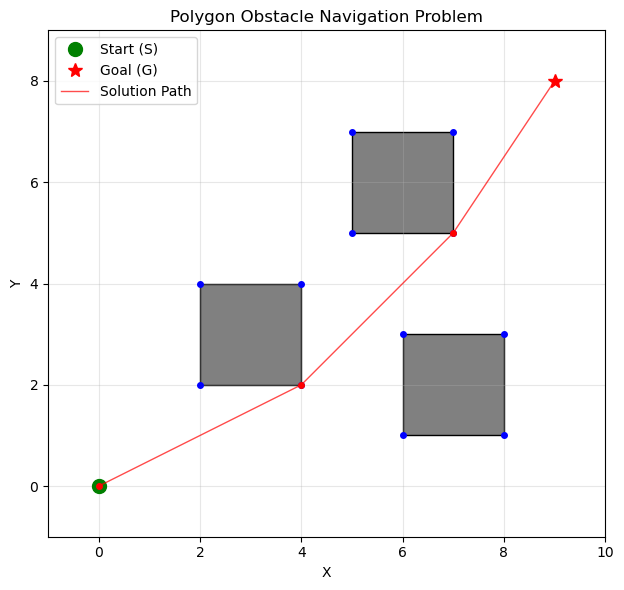

In [147]:
# Visualize the problem with solution
visualize_problem(polygon_problem, solution)